In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [2]:
from google.colab import files
uploaded = files.upload()



Saving travel_tourism_preprocessed.csv to travel_tourism_preprocessed.csv


In [55]:
df = pd.read_csv("travel_tourism_preprocessed.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (2000, 128)


**Checking the dataset:**

In [56]:
print(df.head())

   Avg_Travel_Expense_USD_per_day  Avg_Temperature_C  Avg_Rating  \
0                          174.84               18.0         4.5   
1                           94.41               10.0         4.6   
2                          228.96               18.0         4.7   
3                          120.96               21.5         4.3   
4                          162.10               21.0         3.9   

   Annual_Visitors_M  Destination_Name_Ancient Canyon  \
0               7.45                            False   
1               1.98                            False   
2               0.70                            False   
3               2.24                            False   
4               4.60                            False   

   Destination_Name_Ancient Falls  Destination_Name_Ancient Forest  \
0                           False                            False   
1                           False                            False   
2                           False     

In [57]:
print(df.columns.tolist())

['Avg_Travel_Expense_USD_per_day', 'Avg_Temperature_C', 'Avg_Rating', 'Annual_Visitors_M', 'Destination_Name_Ancient Canyon', 'Destination_Name_Ancient Falls', 'Destination_Name_Ancient Forest', 'Destination_Name_Ancient Pagoda', 'Destination_Name_Ancient Park', 'Destination_Name_Ancient Plaza', 'Destination_Name_Ancient Ruins', 'Destination_Name_Ancient Temple', 'Destination_Name_Ancient Valley', 'Destination_Name_Crystal Beach', 'Destination_Name_Crystal Canyon', 'Destination_Name_Crystal Falls', 'Destination_Name_Crystal Forest', 'Destination_Name_Crystal Pagoda', 'Destination_Name_Crystal Park', 'Destination_Name_Crystal Plaza', 'Destination_Name_Crystal Ruins', 'Destination_Name_Crystal Temple', 'Destination_Name_Crystal Valley', 'Destination_Name_Golden Beach', 'Destination_Name_Golden Canyon', 'Destination_Name_Golden Falls', 'Destination_Name_Golden Forest', 'Destination_Name_Golden Pagoda', 'Destination_Name_Golden Park', 'Destination_Name_Golden Plaza', 'Destination_Name_Gold

In [61]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 128 entries, Avg_Travel_Expense_USD_per_day to UNESCO_Site_Yes
dtypes: bool(124), float64(4)
memory usage: 304.8 KB
None


**Separate X and y:**

In [62]:
X = df.drop("Annual_Visitors_M", axis=1)
y = df["Annual_Visitors_M"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 127)
y shape: (2000,)


In [11]:
print(X.dtypes.value_counts())

bool       124
float64      3
Name: count, dtype: int64


In [63]:
X = X.astype(float)
print("All features converted to numerical format.")

All features converted to numerical format.


**Train/Test Split:**

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1600, 127)
Testing data: (400, 127)


**Creating the 4 ML models:**

In [65]:
linear_model = LinearRegression()
decision_tree_model = DecisionTreeRegressor(
    random_state=42
)
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
gradient_boosting_model = GradientBoostingRegressor(
    random_state=42
)

**Training Model 1: Linear Regression**

In [66]:
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
print("Linear Regression training completed.")

Linear Regression training completed.


**Train Model 2: Decision Tree**

In [67]:
decision_tree_model.fit(X_train, y_train)
decision_tree_pred = decision_tree_model.predict(X_test)
print("Decision Tree training completed.")

Decision Tree training completed.


**Train Model 3: Random Forest**

In [68]:
random_forest_model.fit(X_train, y_train)
random_forest_pred = random_forest_model.predict(X_test)
print("Random Forest training completed.")

Random Forest training completed.


**Train Model 4: Gradient Boosting**

In [69]:
gradient_boosting_model.fit(X_train, y_train)
gradient_boosting_pred = gradient_boosting_model.predict(X_test)
print("Gradient Boosting training completed.")

Gradient Boosting training completed.


**Calculating performance:**

In [70]:
# Linear Regression
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)


# Decision Tree
dt_mae = mean_absolute_error(y_test, decision_tree_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, decision_tree_pred))
dt_r2 = r2_score(y_test, decision_tree_pred)


# Random Forest
rf_mae = mean_absolute_error(y_test, random_forest_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, random_forest_pred))
rf_r2 = r2_score(y_test, random_forest_pred)


# Gradient Boosting
gb_mae = mean_absolute_error(y_test, gradient_boosting_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gradient_boosting_pred))
gb_r2 = r2_score(y_test, gradient_boosting_pred)

print("Performance metrics calculated successfully!")

Performance metrics calculated successfully!


**Creating comparison table:**

In [83]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        linear_mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE": [
        linear_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],

    "R2 Score": [
        linear_r2,
        dt_r2,
        rf_r2,
        gb_r2
    ]
})

print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  2.510285  2.931963 -0.080847
1      Decision Tree  3.259700  4.005499 -1.017253
2      Random Forest  2.511529  2.914497 -0.068008
3  Gradient Boosting  2.520297  2.904889 -0.060978


**Round the results:**

In [72]:
results["MAE"] = results["MAE"].round(3)
results["RMSE"] = results["RMSE"].round(3)
results["R2 Score"] = results["R2 Score"].round(3)
print(results)

               Model    MAE   RMSE  R2 Score
0  Linear Regression  2.510  2.932    -0.081
1      Decision Tree  3.260  4.005    -1.017
2      Random Forest  2.512  2.914    -0.068
3  Gradient Boosting  2.520  2.905    -0.061


**Finding the best model:**

In [73]:
best_index = results["R2 Score"].idxmax()

best_model_name = results.loc[best_index, "Model"]
best_r2 = results.loc[best_index, "R2 Score"]

print("================================")
print("BEST MODEL")
print("================================")
print("Model:", best_model_name)
print("R2 Score:", best_r2)

BEST MODEL
Model: Gradient Boosting
R2 Score: -0.061


**Creating the graph:**

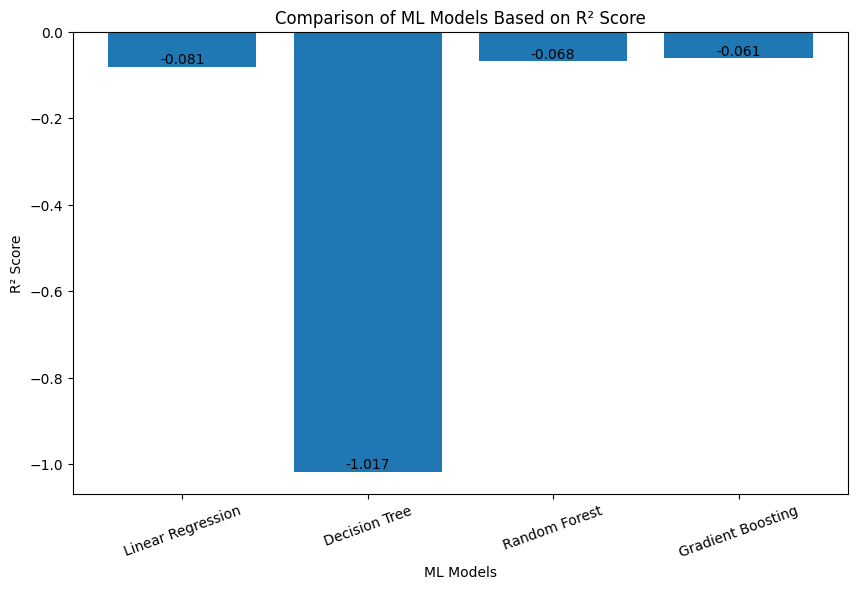

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bars = plt.bar(
    results["Model"],
    results["R2 Score"]
)

plt.xlabel("ML Models")
plt.ylabel("R² Score")
plt.title("Comparison of ML Models Based on R² Score")

plt.xticks(rotation=20)

for bar, value in zip(bars, results["R2 Score"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.show()

In [88]:
print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  2.510285  2.931963 -0.080847
1      Decision Tree  3.259700  4.005499 -1.017253
2      Random Forest  2.511529  2.914497 -0.068008
3  Gradient Boosting  2.520297  2.904889 -0.060978


In [89]:
print("Target values:")
print(y.describe())

Target values:
count    2000.000000
mean        5.183250
std         2.752695
min         0.500000
25%         2.760000
50%         5.235000
75%         7.510000
max        10.000000
Name: Annual_Visitors_M, dtype: float64


In [90]:
print("Training target mean:", y_train.mean())
print("Testing target mean:", y_test.mean())

Training target mean: 5.139575
Testing target mean: 5.357950000000001


**Selecting the actual trained model:**

In [76]:
model_dictionary = {
    "Linear Regression": linear_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model,
    "Gradient Boosting": gradient_boosting_model
}

best_model = model_dictionary[best_model_name]

print("Selected model:", best_model_name)

Selected model: Gradient Boosting


**Saving the best model:**

In [77]:
joblib.dump(
    best_model,
    "best_travel_demand_model.pkl"
)
print("Best model saved successfully!")

Best model saved successfully!


**Testing the saved model:**

In [78]:
loaded_model = joblib.load(
    "best_travel_demand_model.pkl"
)
loaded_predictions = loaded_model.predict(X_test)
print("Saved model loaded successfully!")
print("Sample predictions:")
print(loaded_predictions[:10])

Saved model loaded successfully!
Sample predictions:
[3.43785771 5.13337062 5.134366   4.18707418 4.30268542 5.14382169
 4.67439101 3.80326077 4.65727737 4.65035124]


In [91]:
from google.colab import files
files.download("best_travel_demand_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>